In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision import transforms as T
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt

In [2]:
mnist_transform = T.Compose(
    [
        T.Resize((64, 64)),
        T.ToTensor()
    ]
)

train_dataset = MNIST('datasets', download = True, train = True, transform = mnist_transform)
valid_dataset = MNIST('datasets', download = True, train = False, transform = mnist_transform)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True, num_workers = 4, pin_memory = True)
valid_loader = DataLoader(valid_dataset, batch_size = 64, shuffle = False, num_workers = 4, pin_memory = True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.32MB/s]


In [3]:
train_dataset[0]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 5)

In [4]:
class Block(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, stride: int = 1, upsample: bool = False):
        super().__init__()
        self.upsample = upsample
        self.conv = nn.Conv2d(
            in_channels = in_channels,
            out_channels = out_channels,
            kernel_size = kernel_size,
            stride = stride,
            padding = 1,
            bias = False
        )
        self.norm = nn.BatchNorm2d(
            out_channels
        )
        self.act = nn.ReLU(0.2)
    
    def forward(self, x):
        if self.upsample:
            x = nn.functional.interpolate(x, scale_factor = 2, mode = 'bilinear', align_corners = False, recompute_scale_factor = False)

        return self.act(self.norm(self.conv(x)))

In [5]:
class AutoEncoder(nn.Module):
    def __init__(self, in_channels: int , base_size: int = 32, base_block = Block, num_blocks: int = 5):
        super().__init__()
        self.base_size = base_size

        encoder_blocks = []
        for i in range(num_blocks):
            encoder_blocks.append(
                base_block(
                    in_channels = in_channels if i==0 else base_size,
                    out_channels = base_size,
                    kernel_size = 3,
                    stride = 2
                )
            )
        encoder_blocks.append(
            base_block(
                in_channels = base_size,
                out_channels = base_size,
                kernel_size = 3,
            ).conv
        )
        self.encoder = nn.Sequential(*encoder_blocks)

        decoder_blocks = []
        for i in range(num_blocks):
            decoder_blocks.append(
                base_block(
                    in_channels = base_size,
                    out_channels = base_size,
                    kernel_size = 3,
                    upsample = True
                )
            )
        decoder_blocks.append(
            base_block(
                in_channels = base_size,
                out_channels = in_channels,
                kernel_size = 3
            ).conv
        )
        decoder_blocks.append(nn.Sigmoid())
        self.decoder = nn.Sequential(*decoder_blocks)
        self.flatten = nn.Flatten()

    def forward(self, x):
        # x.shape = [batch_size, in_channels, N, N]
        x = self.encoder(x)
        # x.shape = [batch_size, in_channels, N / (2^num_blocks), N / (2^num_blocks)]
        x = self.decoder(x)
        # x.shape = [batch_size, in_channels, N, N]
        return x

    @torch.inference_mode()
    def encode(self, x):
        return self.flatten(self.encoder(x))

    @torch.inference_mode()
    def decode(self, x):
        latent_size = int(math.sqrt(x.shape[1] // self.base_size))
        return self.decoder(x.view(-1, self.base_size, latent_size, latent_size))

In [6]:
from tqdm import tqdm
def train(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for x, _ in tqdm(loader, desc = 'Train'):
        x = x.to(device)
        
        optimizer.zero_grad()
        
        output = model(x)
        
        loss = loss_fn(output, x)
        total_loss += loss.item()
        
        loss.backward()
        
        optimizer.step()
    total_loss /= len(loader)
    return total_loss

In [7]:
@torch.inference_mode()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    for x, _ in tqdm(loader, desc = 'Evaluate'):
        x = x.to(device)

        output = model(x)
        
        loss = loss_fn(output, x)
        total_loss += loss.item()
        
    total_loss /= len(loader)
    return total_loss

In [8]:
from torchvision.utils import make_grid

@torch.inference_mode()
def visualize(model, xs):
    model.eval()
    to_pil = T.ToPILImage()

    output = model(xs)

    plt.figure(figsize = (16, 10))

    plt.imshow(
        to_pil(
            torch.cat(
                (
                    make_grid(xs[:10], nrow = 10, pad_value = 1),
                    make_grid(output[:10], nrow = 10, pad_value = 1),
                ),
                dim = 1
            )
        )
    )
    plt.axis('off')
    plt.show()

In [9]:
def plot_stats(
    train_loss_history: list[float],
    valid_loss_history: list[float],
    title
):
    plt.figure(figsize = (16, 10))
    plt.title(title)
    plt.plot(train_loss_history, label = 'Train Loss')
    plt.plot(valid_loss_history, label = 'Train Loss')
    plt.legend()
    plt.grid()
    plt.show()

In [10]:
from IPython.display import clear_output
def whole_train_value_cycle(
    model,
    train_loader,
    valid_loader,
    optimizer,
    loss_fn,
    num_epochs: int,
    title: str
):
    train_loss_history, valid_loss_history = [], []
    for epoch in range(num_epochs):
        train_loss = train(model, train_loader, optimizer, loss_fn)
        valid_loss = evaluate(model, valid_loader, loss_fn)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        clear_output(wait = True)
        plot_stats(
            train_loss_history,
            valid_loss_history,
            title
        )

In [11]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = AutoEncoder(in_channels = 1).to(device)

In [12]:
from torch.optim import Adam

optimizer = Adam(model.parameters(), lr = 1e-3)
loss_fn = nn.MSELoss()

In [13]:
model

AutoEncoder(
  (encoder): Sequential(
    (0): Block(
      (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
    )
    (1): Block(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
    )
    (2): Block(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
    )
    (3): Block(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
    )
   

In [14]:
'''
whole_train_value_cycle(
    model,
    train_loader,
    valid_loader,
    optimizer,
    loss_fn,
    2,
    'Default AutoEncoder'
)
'''

"\nwhole_train_value_cycle(\n    model,\n    train_loader,\n    valid_loader,\n    optimizer,\n    loss_fn,\n    2,\n    'Default AutoEncoder'\n)\n"

### Создадим DenoisingAutoEncoder (зашумляем данные)

In [15]:
class DenoisingBlock(Block):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, stride: int = 1, upsample: bool = False):
        super().__init__(in_channels, out_channels, kernel_size, stride, upsample)
        self.drop = nn.Dropout(0.2)

    def forward(self, x):
        if self.upsample:
            x = nn.functional.interpolate(x, scale_factor = 2, mode = 'bilinear', align_corners = False, recompute_scale_factor = False)

        if self.training:
            x = x + torch.rand_like(x) * 0.05

        return self.act(self.norm(self.conv(x)))

In [16]:
class DenoisingAutoEncoder(AutoEncoder):
    def __init__(self, in_channels: int, base_size: int = 32, base_block: nn.Module = DenoisingBlock, num_blocks: int = 5):
        super().__init__(in_channels, base_size, base_block, num_blocks)

    def forward(self, x):
        if self.training:
            x = torch.clip(x + torch.rand_like(x) * 0.1, min = 0.0, max = 1.0)
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [17]:
denoising_model = DenoisingAutoEncoder(in_channels = 1).to(device)
denoising_optimizer = Adam(denoising_model.parameters(), lr = 1e-3)

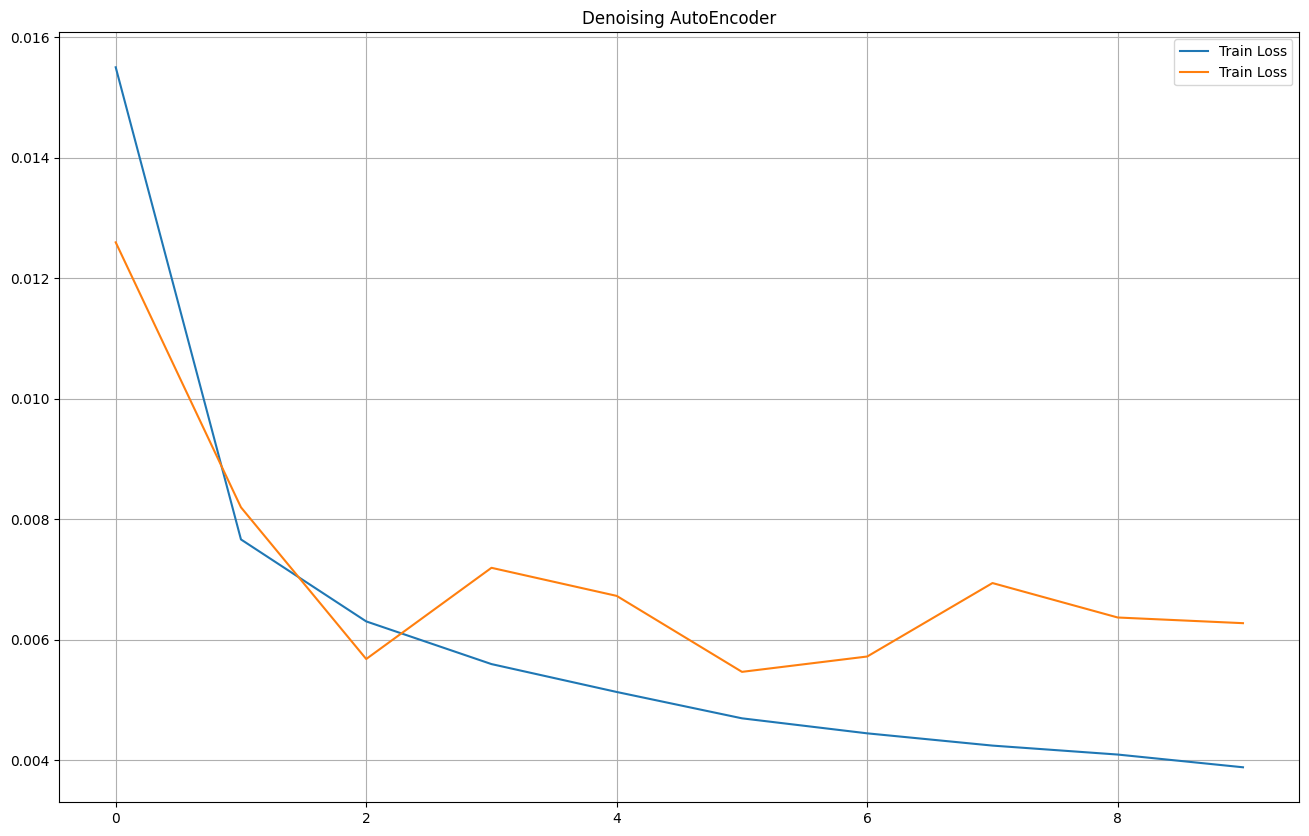

In [18]:
whole_train_value_cycle(
    denoising_model,
    train_loader,
    valid_loader,
    denoising_optimizer,
    loss_fn,
    10,
    "Denoising AutoEncoder"
)

In [36]:
@torch.inference_mode()
def get_latent_labels(model, loader, count: int = None):
    model.eval()
    
    total = 0
    latent = []
    labels = []

    for x, y in loader:
        z = model.encode(x.to(device)).cpu()

        total += y.shape[0]
        latent.append(z)
        labels.append(y)

        if count is None or total > count:
            break

    latent = torch.cat(latent)[:count]
    labels = torch.cat(labels)[:count]

    return latent, labels

In [37]:
X_train, y_train = get_latent_labels(denoising_model, train_loader, 1000)
X_test, y_test = get_latent_labels(denoising_model, valid_loader, 10000)

In [38]:
def save_embeddings(x_train, y_train, x_valid, y_valid):
    print(x_train.shape[0])
    print(y_train.shape[0])
    print(x_valid.shape[0])
    print(y_valid.shape[0])
    
    assert x_train.shape[0] == 1000
    assert x_valid.shape[0] == 10000
    
    assert y_train.shape[0] == 1000
    assert y_valid.shape[0] == 10000

    
    torch.save(
        {
            'x_train': x_train,
            'y_train': y_train,
            'x_valid': x_valid,
            'y_valid': y_valid
        },
        'embeddings.pt'
    )
    

In [39]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state = 0)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [41]:
predictions = clf.predict(X_test)

print(f'Accuracy: {(predictions == y_test.numpy()).mean()}')

Accuracy: 0.9362


In [42]:
save_embeddings(X_train, y_train, X_test, y_test)

1000
1000
10000
10000
